In [24]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("SamplePortfolio.csv")
print(f"The dataset has {len(df)} rows and {len(df.columns)} columns")
print(df.head())

The dataset has 533 rows and 24 columns
   POSITIONS            UNIQUE ID ID TYPE                                NAME  \
0        NaN  CX_US4642851053_NYQ    ISIN                  iShares Gold Trust   
1        NaN  CX_US0584981064_NYQ    ISIN                           BALL CORP   
2        NaN  CX_IE00BY7QL619_NYQ    ISIN  JOHNSON CONTROLS INTERNATIONAL PLC   
3        NaN  CX_US1912161007_NYQ    ISIN                           COCA-COLA   
4        NaN  CX_US46434G1031_NYQ    ISIN  iShares Core MSCI Emerging Markets   

          PORTFOLIO  POSITION UNITS  HAS_LOOKTHROUGH  FUND_NAV  PRICE  \
0  Sample Portfolio             100            False       NaN  11.95   
1  Sample Portfolio             100            False       NaN  42.42   
2  Sample Portfolio             100            False       NaN  44.00   
3  Sample Portfolio             100            False       NaN  44.67   
4  Sample Portfolio             100            False       NaN  52.23   

  CURRENCY  ... esg_Controversy es

In [25]:
sector_counts = df["sector"].value_counts()
sector_counts = sector_counts.head(10)
print("Top 10 sectors:")
print(sector_counts)

Top 10 sectors:
sector
Consumer Discretionary    83
Information Technology    74
Industrials               73
Financials                68
Health Care               67
Consumer Staples          34
Energy                    34
Real Estate               33
Utilities                 29
Materials                 25
Name: count, dtype: int64


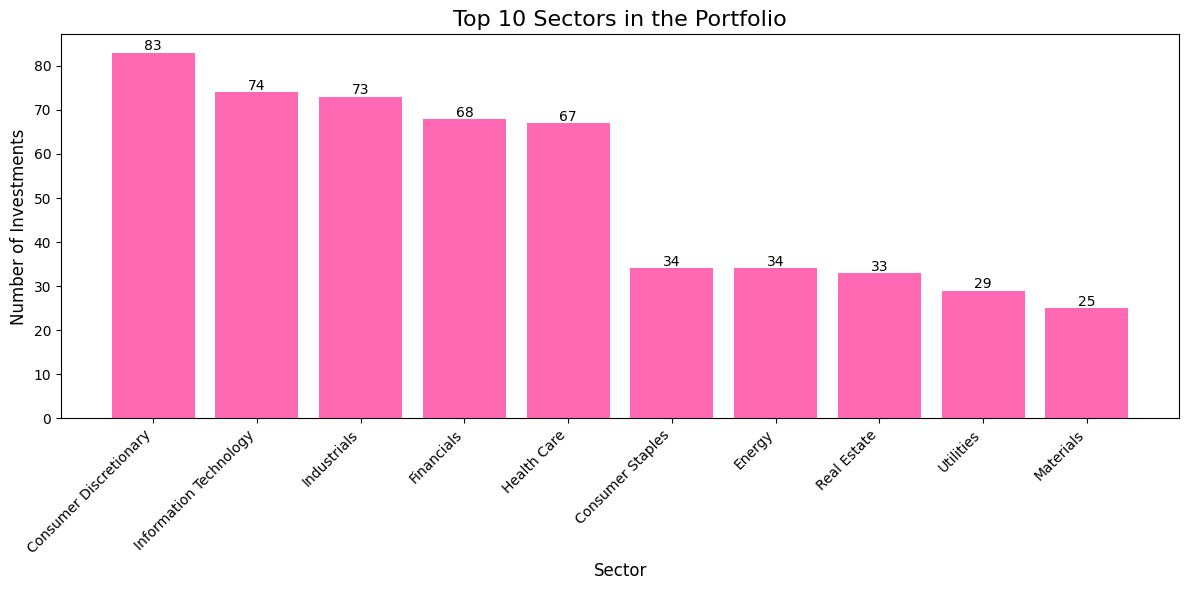

In [26]:
plt.figure(figsize=(12, 6))
plt.bar(sector_counts.index, sector_counts.values, color="#ff69b4")
plt.title("Top 10 Sectors in the Portfolio", fontsize=16)
plt.xlabel("Sector", fontsize=12)
plt.ylabel("Number of Investments", fontsize=12)
plt.xticks(rotation=45, ha="right")
for i, value in enumerate(sector_counts.values):
    plt.text(i, value + 0.5, str(value), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

In [29]:
esg_columns = ["esg_Environmental", "esg_Governance", "esg_Social", "esg_Sustainability", "esg_Controversy"]
esg_averages = df[esg_columns].mean()
print("Average ESG scores across the portfolio:")
print(esg_averages.round(2))

Average ESG scores across the portfolio:
esg_Environmental     5.48
esg_Governance        5.39
esg_Social            5.48
esg_Sustainability    5.48
esg_Controversy       5.63
dtype: float64


In [30]:
controversy_columns = ["has_Tobacco", "has_Alcohol", "has_Gambling", "has_Military", "has_Fossil Fuels"]
controversy_counts = df[controversy_columns].sum()
controversy_counts.index = ["Tobacco", "Alcohol", "Gambling", "Military", "Fossil Fuels"]
print("Number of companies flagged per category:")
print(controversy_counts)

Number of companies flagged per category:
Tobacco          6
Alcohol          4
Gambling         6
Military        18
Fossil Fuels    38
dtype: int64


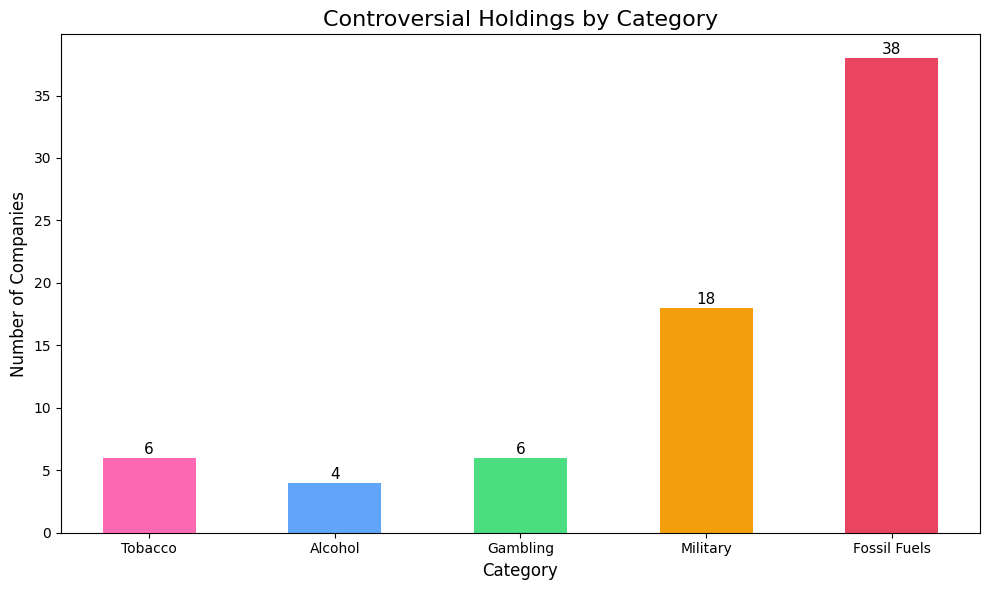

In [31]:
plt.figure(figsize=(10, 6))
colors = ["#ff69b4", "#60a5fa", "#4ade80", "#f59e0b", "#e94560"]
plt.bar(controversy_counts.index, controversy_counts.values, color=colors, width=0.5)
plt.title("Controversial Holdings by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Companies", fontsize=12)
for i, value in enumerate(controversy_counts.values):
    plt.text(i, value + 0.3, str(value), ha="center", fontsize=11)
plt.tight_layout()
plt.show()

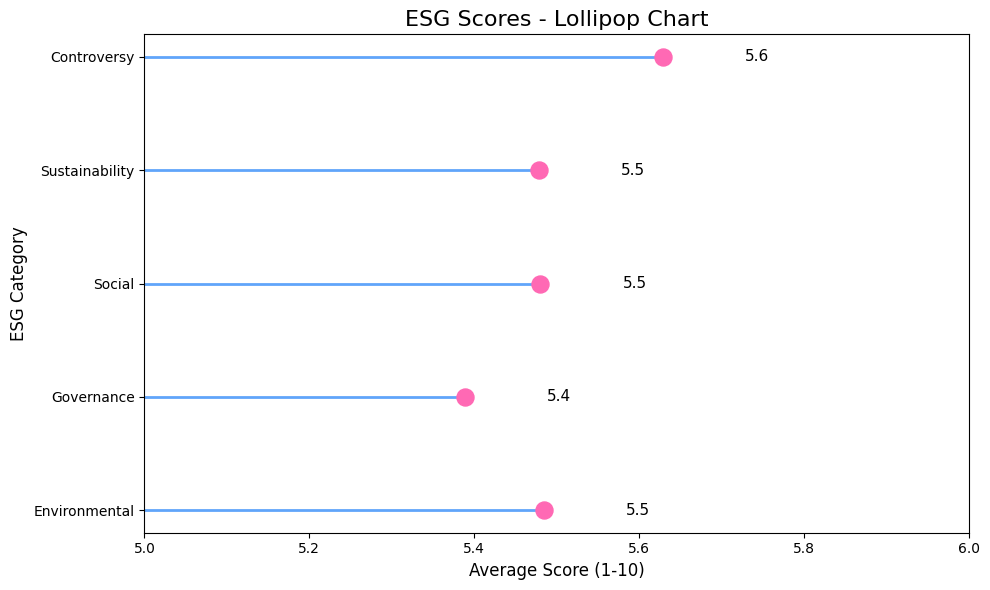

In [33]:
plt.figure(figsize=(10, 6))
labels = ["Environmental", "Governance", "Social", "Sustainability", "Controversy"]
values = esg_averages.values
plt.hlines(labels, 0, values, color="#60a5fa", linewidth=2)
plt.scatter(values, labels, color="#ff69b4", s=150, zorder=3)
plt.title("ESG Scores - Lollipop Chart", fontsize=16)
plt.xlabel("Average Score (1-10)", fontsize=12)
plt.ylabel("ESG Category", fontsize=12)
plt.xlim(5, 6)
for i, value in enumerate(values):
    plt.text(value + 0.1, i, f"{value:.1f}", va="center", fontsize=11)
plt.tight_layout()
plt.show()

In [44]:

df_prices = df.dropna(subset=["PRICE"])
df_prices = df_prices.groupby("NAME")["PRICE"].max().reset_index()
top10_prices = df_prices.sort_values("PRICE", ascending=False).head(10)
print("Top 10 most expensive stocks:")
print(top10_prices)

Top 10 most expensive stocks:
                           NAME    PRICE
80         BOOKING HOLDINGS INC  2010.60
31               AMAZON COM INC  1812.97
28         ALPHABET INC CLASS A  1199.10
29         ALPHABET INC CLASS C  1186.96
266      INTUITIVE SURGICAL INC   946.65
62                 AUTOZONE INC   716.17
318          METTLER TOLEDO INC   598.11
77                BLACKROCK INC   504.89
111  CHIPOTLE MEXICAN GRILL INC   454.83
182            EQUINIX REIT INC   437.19


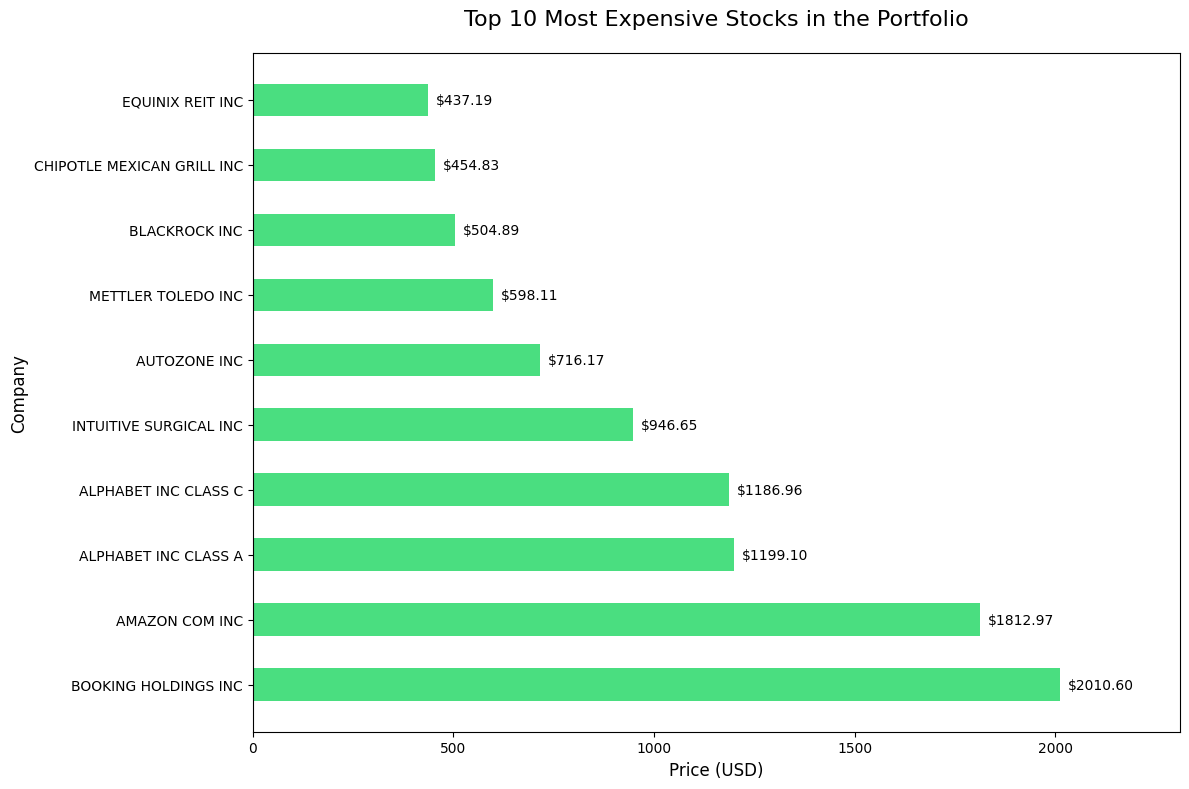

In [45]:

df_prices = df.dropna(subset=["PRICE"])
df_prices = df_prices.groupby("NAME")["PRICE"].max().reset_index()
top10_prices = df_prices.sort_values("PRICE", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top10_prices["NAME"], top10_prices["PRICE"], color="#4ade80", height=0.5)
ax.set_title("Top 10 Most Expensive Stocks in the Portfolio", fontsize=16, pad=20)
ax.set_xlabel("Price (USD)", fontsize=12)
ax.set_ylabel("Company", fontsize=12)
ax.set_xlim(0, top10_prices["PRICE"].max() + 300)
for i, value in enumerate(top10_prices["PRICE"]):
    ax.text(value + 20, i, f"${value:.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()


In [47]:
avg_price_per_sector = df.groupby("sector")["PRICE"].mean()
avg_price_per_sector = avg_price_per_sector.sort_values(ascending=False)
avg_price_per_sector = avg_price_per_sector.round(2)
print("Average stock price per sector:")
print(avg_price_per_sector)

Average stock price per sector:
sector
Health Care                162.16
Consumer Discretionary     147.63
Information Technology     136.39
Industrials                119.25
Diversified                107.61
Materials                  103.18
Real Estate                 98.69
Financials                  96.34
Consumer Staples            77.11
Energy                      73.13
Utilities                   61.34
Cash and/or Derivatives     50.50
Telecommunications          33.75
Commodity                   11.95
Name: PRICE, dtype: float64


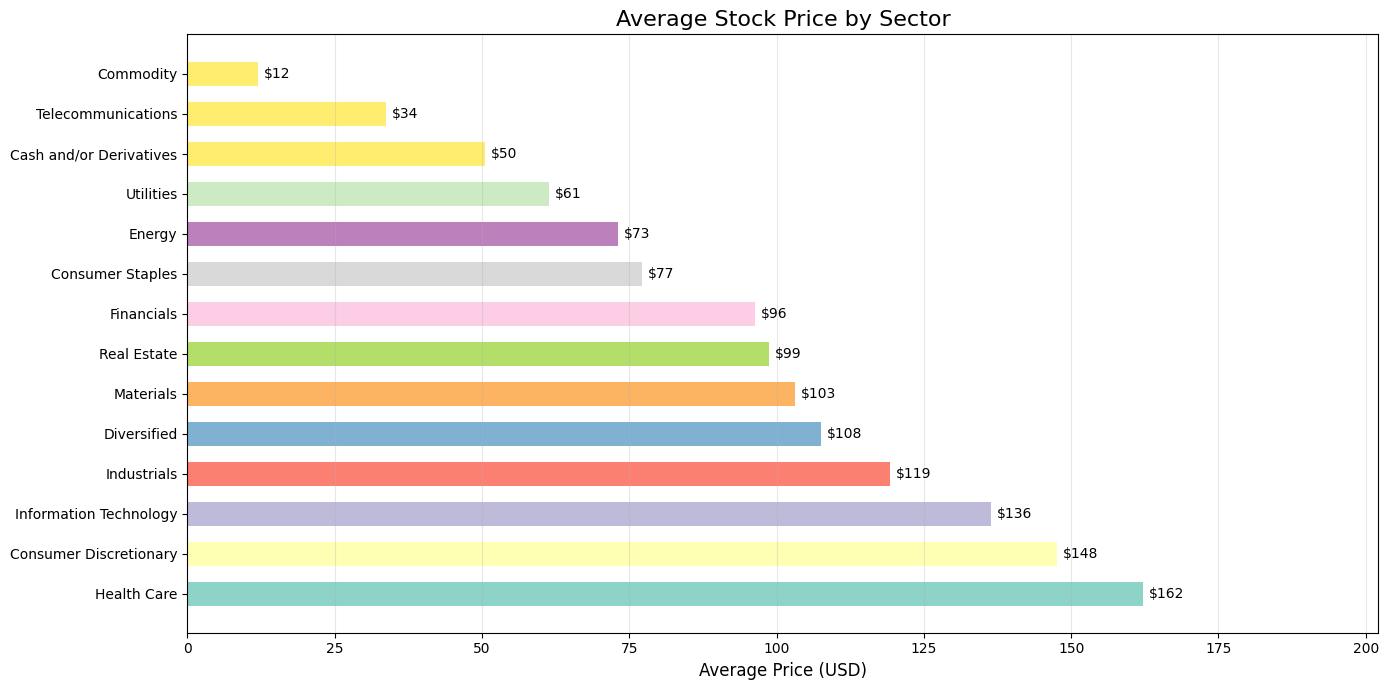

In [50]:
plt.figure(figsize=(14, 7))

colors = plt.cm.Set3(range(len(avg_price_per_sector)))

bars = plt.barh(avg_price_per_sector.index, avg_price_per_sector.values, 
                color=colors, height=0.6)

for i, value in enumerate(avg_price_per_sector.values):
    plt.text(value + 1, i, f"${value:.0f}", va="center", fontsize=10)

plt.title("Average Stock Price by Sector", fontsize=16)
plt.xlabel("Average Price (USD)", fontsize=12)

plt.grid(axis="x", alpha=0.3)

plt.xlim(0, avg_price_per_sector.max() + 40)

plt.tight_layout()
plt.show()

In [51]:
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", "analysis.ipynb"])

print

[NbConvertApp] Converting notebook analysis.ipynb to html
Traceback (most recent call last):
  File "/Users/gabrielebradunaite/financial_project/lib/python3.14/site-packages/nbformat/reader.py", line 19, in parse_json
    nb_dict = json.loads(s, **kwargs)
  File "/opt/homebrew/Cellar/python@3.14/3.14.4/Frameworks/Python.framework/Versions/3.14/lib/python3.14/json/__init__.py", line 352, in loads
    return _default_decoder.decode(s)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "/opt/homebrew/Cellar/python@3.14/3.14.4/Frameworks/Python.framework/Versions/3.14/lib/python3.14/json/decoder.py", line 345, in decode
    obj, end = self.raw_decode(s, idx=_w(s, 0).end())
               ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.14/3.14.4/Frameworks/Python.framework/Versions/3.14/lib/python3.14/json/decoder.py", line 363, in raw_decode
    raise JSONDecodeError("Expecting value", s, err.value) from None
json.decoder.JSONDecodeError: Expecting value: line 1 colu

<function print(*args, sep=' ', end='\n', file=None, flush=False)>